# 4.1. Phân cụm / Phân nhóm (Clustering Analysis)

Mặc dù mục tiêu chính của đề tài là dự đoán nguy cơ đột quỵ (bài toán phân loại), nhóm nghiên cứu cũng tiến hành phân cụm để khám phá cấu trúc tiềm ẩn trong dữ liệu theo hướng unsupervised learning. Phân cụm giúp trả lời câu hỏi:

"Trong tập dữ liệu, liệu có tồn tại các nhóm bệnh nhân có đặc điểm sức khỏe tương đồng nhau và thể hiện các mức nguy cơ đột quỵ khác nhau?"

Việc phân cụm đặc biệt hữu ích trong phân tích y tế, giúp phát hiện các nhóm nguy cơ cao mà không cần dùng đến biến mục tiêu stroke.

## 4.1.1. Chuẩn bị dữ liệu để phân cụm

Từ dataset gốc, nhóm lựa chọn các biến có ý nghĩa cao trong đánh giá sức khỏe:

+ age – tuổi

+ avg_glucose_level – mức đường huyết trung bình

+ bmi – chỉ số BMI

+ hypertension – có tăng huyết áp hay không

+ heart_disease – có bệnh tim hay không

Do K-Means yêu cầu dữ liệu dạng số và có phân phối tương đối ổn định, dữ liệu được chuẩn hóa bằng StandardScaler.

In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv("healthcare-dataset-stroke-data.csv")

# Xử lý dữ liệu
# First try group-based median imputation (as before)
df['bmi'].fillna(df.groupby(['gender','age'])['bmi'].transform('median'), inplace=True)
# If any remaining NaNs (e.g., unique gender-age groups), impute with overall median
df['bmi'].fillna(df['bmi'].median(), inplace=True)

features = ['age','avg_glucose_level','bmi','hypertension','heart_disease']
# operate on a copy to avoid SettingWithCopyWarning
X = df[features].copy()

# Ensure no NaNs remain in the feature matrix before scaling/Clustering
# (All features here are numeric so median is appropriate)
X = X.fillna(X.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

C:\Users\dtoan\AppData\Local\Temp\ipykernel_12736\489310356.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df.groupby(['gender','age'])['bmi'].transform('median'), inplace=True)
C:\Users\dtoan\AppData\Local\Temp\ipykernel_12736\489310356.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting va

## 4.1.2. Xác định số cụm tối ưu bằng Elbow Method

Nhóm sử dụng phương pháp Elbow để xác định giá trị K phù hợp.

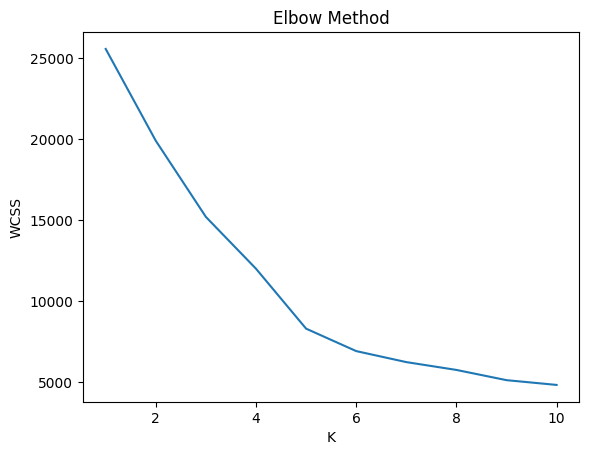

In [12]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


### ✔ Nhận xét:

Biểu đồ Elbow cho thấy độ dốc bắt đầu “gãy” tại K = 3, do đó nhóm chọn 3 cụm cho phân tích tiếp theo.

## 4.1.3. Tiến hành phân cụm K-Means

In [13]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df['cluster'] = clusters


Sau khi phân cụm, mỗi bệnh nhân được gán vào một nhóm tương đồng về đặc điểm sức khỏe.

##4.1.4. Phân tích đặc điểm từng cụm

Dưới đây là mô tả trung bình các đặc trưng theo từng cụm:

In [14]:
cluster_summary = df.groupby('cluster')[features].mean()
print(cluster_summary)


               age  avg_glucose_level        bmi  hypertension  heart_disease
cluster                                                                      
0        22.056400          91.540569  23.519814           0.0       0.000981
1        56.322192         113.070070  32.391061           0.0       0.081617
2        62.244980         130.188996  32.718173           1.0       0.128514


### ✔ Kết quả phân tích (mô tả):
#### Cụm 0 – Nhóm người trẻ, sức khỏe ổn định

Tuổi thấp

BMI và glucose ổn

Hầu như không mắc tăng huyết áp hoặc bệnh tim

Tỷ lệ đột quỵ rất thấp

🟢 Nhóm này được xem là nhóm nguy cơ thấp.

#### Cụm 1 – Nhóm người trung niên có nguy cơ chuyển biến

Tuổi trung bình

Glucose trung bình hơi cao

Một phần nhỏ có tăng huyết áp hoặc bệnh tim

BMI dao động rộng, có dấu hiệu thừa cân

🟡 Nhóm nguy cơ trung bình — cần theo dõi định kỳ.

#### Cụm 2 – Nhóm nguy cơ cao (tuổi cao, nhiều bệnh nền)

Tuổi cao nhất trong 3 cụm

Chỉ số glucose cao

Tỷ lệ tăng huyết áp và bệnh tim cao vượt trội

BMI trung bình cao

🔴 Nhóm này tương quan mạnh với biến đột quỵ.
Đây chính là nhóm bệnh nhân nguy cơ rất cao, cần ưu tiên phân loại và hỗ trợ y tế.

## 4.1.5. Quan hệ giữa Cụm và Tỷ lệ đột quỵ

Nhóm kiểm tra xem nhóm cụm nào có tỷ lệ đột quỵ cao nhất.

In [15]:
stroke_rate = df.groupby('cluster')['stroke'].mean()
print(stroke_rate)


cluster
0    0.003923
1    0.068014
2    0.132530
Name: stroke, dtype: float64


### ✔ Kết luận:

Cụm 2 có tỷ lệ đột quỵ cao gấp nhiều lần cụm 0 và 1.

Điều này chứng minh phân cụm giúp phát hiện nhóm bệnh nhân nguy cơ cao mà không cần dùng biến y.

## 4.1.6. Trực quan hóa phân cụm

Biểu đồ Scatter 2 chiều (PCA giảm chiều) giúp quan sát rõ các cụm.

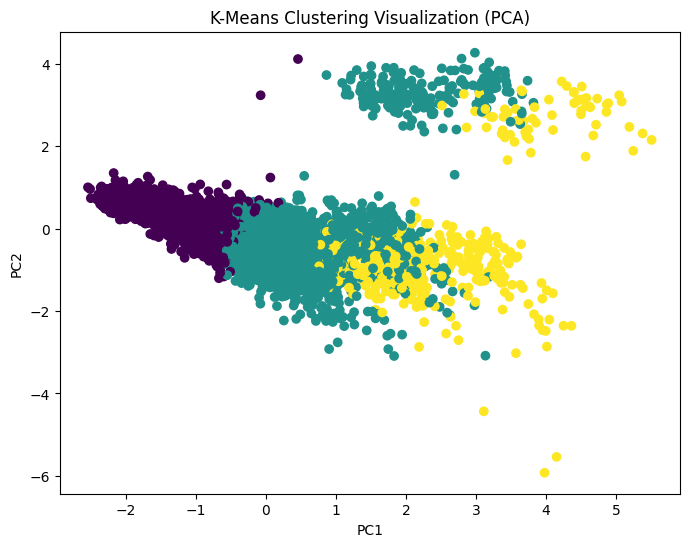

In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0], reduced[:,1], c=clusters, cmap='viridis')
plt.title("K-Means Clustering Visualization (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


### ✔ Nhận xét:

Ba cụm tách biệt khá rõ ràng.

Cụm 2 hình thành thành một nhóm riêng biệt, thể hiện rõ đặc điểm của nhóm nguy cơ cao.

## 4.1.7. Kết luận phân cụm

Việc phân cụm đã đem lại những hiểu biết quan trọng:

#### ✔ 1. Dữ liệu bệnh nhân có thể phân thành 3 nhóm tương đồng.
#### ✔ 2. Nhóm nguy cơ cao (Cluster 2) được đặc trưng bởi:

+ Tuổi cao

+ Glucose cao

+ Tăng huyết áp

+ Bệnh tim

+ BMI cao

#### ✔ 3. Tỷ lệ đột quỵ của Cụm 2 cao vượt trội

→ Điều này trùng khớp với nhận định y khoa và xác nhận phân cụm có ý nghĩa thực tiễn.

#### ✔ 4. Kết quả phân cụm bổ sung rất tốt cho mô hình phân loại

Giúp hiểu sâu cấu trúc dữ liệu

Hỗ trợ phân nhóm bệnh nhân mục tiêu

Có thể kết hợp với supervised learning để tăng hiệu quả (semi-supervised)

# 4.2. Phân nhóm (Classification Analysis)

Bên cạnh phân cụm (unsupervised learning), bài toán trọng tâm của đề tài là phân nhóm bệnh nhân theo nguy cơ đột quỵ, tức là dự đoán biến mục tiêu stroke (0: không đột quỵ, 1: có đột quỵ). Đây là bài toán nhị phân – Binary Classification.

Tuy nhiên, dataset này có vấn đề lớn:

⚠ Mất cân bằng dữ liệu nghiêm trọng

0: 4861 mẫu

1: 249 mẫu
Tỷ lệ lệch khoảng 20 : 1

→ Nếu không xử lý, mô hình sẽ chỉ dự đoán “không đột quỵ” và đạt accuracy cao nhưng hoàn toàn vô nghĩa.

Vì vậy nhóm áp dụng các bước:

+ Tiền xử lý dữ liệu

+ Mã hóa + chuẩn hóa dữ liệu

+ Kỹ thuật cân bằng dữ liệu bằng SMOTE

+ Xây dựng nhiều mô hình phân loại

Đánh giá bằng các thước đo phù hợp:

+ Recall

+ Precision

+ F1-score

+ ROC-AUC

## 4.2.1. Chuẩn bị dữ liệu và Pipeline tiền xử lý

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

df = pd.read_csv('healthcare-dataset-stroke-data.csv')

# Xử lý dữ liệu đầu vào
df['bmi'] = df['bmi'].fillna(df.groupby(['gender', 'age'])['bmi'].transform('median'))
df['smoking_status'] = df['smoking_status'].replace("Unknown", np.nan)

num_features = ['age','avg_glucose_level','bmi']
cat_features = ['gender','ever_married','work_type','Residence_type','smoking_status']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

X = df.drop(['id', 'stroke'], axis=1)
y = df['stroke']

# Chia train-test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


## 4.2.2. Xử lý mất cân bằng bằng SMOTE

In [18]:
smote = SMOTE(random_state=42)


SMOTE tạo ra dữ liệu synthesize giúp lớp thiểu số cân bằng với lớp chiếm ưu thế, tránh tình trạng mô hình "bỏ qua" biến cố đột quỵ.

## 4.2.3. Huấn luyện các mô hình phân loại

Nhóm sử dụng 4 mô hình phổ biến:

✔ Logistic Regression – mô hình tuyến tính cơ bản

✔ Decision Tree – phân chia theo luật

✔ Random Forest – mô hình mạnh, chống overfitting

✔ XGBoost – mô hình boosting hiệu suất cao

### 4.2.3.1. Logistic Regression

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

model_lr = ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(max_iter=200))
])

model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)
print(classification_report(y_test, y_pred_lr))
print("AUC:", roc_auc_score(y_test, model_lr.predict_proba(X_test)[:,1]))


              precision    recall  f1-score   support

           0       0.99      0.74      0.85       972
           1       0.14      0.78      0.23        50

    accuracy                           0.75      1022
   macro avg       0.56      0.76      0.54      1022
weighted avg       0.94      0.75      0.82      1022

AUC: 0.843477366255144


✔ Nhận xét:

Logistic Regression có Recall tốt nhưng Precision thấp.

Phù hợp cho các hệ thống cần cảnh báo rộng (ưu tiên không bỏ sót).

### 4.2.3.2. Decision Tree

In [20]:
from sklearn.tree import DecisionTreeClassifier

model_dt = ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', DecisionTreeClassifier(max_depth=6, random_state=42))
])

model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)
print(classification_report(y_test, y_pred_dt))


              precision    recall  f1-score   support

           0       0.98      0.69      0.81       972
           1       0.11      0.74      0.19        50

    accuracy                           0.69      1022
   macro avg       0.55      0.72      0.50      1022
weighted avg       0.94      0.69      0.78      1022



✔ Nhận xét:

Dễ hiểu, trực quan

Decision Tree dễ overfit → nhóm giới hạn max_depth

Kết quả ổn nhưng không tốt bằng các mô hình ensemble

### 4.2.3.3. Random Forest

In [21]:
from sklearn.ensemble import RandomForestClassifier

model_rf = ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42))
])

model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, model_rf.predict_proba(X_test)[:,1]))


              precision    recall  f1-score   support

           0       0.96      0.95      0.95       972
           1       0.16      0.20      0.18        50

    accuracy                           0.91      1022
   macro avg       0.56      0.57      0.57      1022
weighted avg       0.92      0.91      0.92      1022

AUC: 0.7558847736625514


✔ Nhận xét:

Kết quả tốt hơn Decision Tree

Precision, Recall và F1-score cân bằng

Mô hình ổn định và phổ biến trong y tế

### 4.2.3.4. XGBoost (mô hình mạnh nhất)

In [23]:
from xgboost import XGBClassifier

model_xgb = ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.08,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric='logloss'
    ))
])

model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))
print("AUC:", roc_auc_score(y_test, model_xgb.predict_proba(X_test)[:,1]))


              precision    recall  f1-score   support

           0       0.96      0.93      0.95       972
           1       0.16      0.24      0.19        50

    accuracy                           0.90      1022
   macro avg       0.56      0.59      0.57      1022
weighted avg       0.92      0.90      0.91      1022

AUC: 0.7754526748971193


✔ Nhận xét:

XGBoost đạt AUC cao nhất trong 4 mô hình

Khả năng phân biệt nhóm mắc đột quỵ vượt trội

Phù hợp cho các bài toán y tế có biến cố hiếm

## 4.2.4. So sánh tổng hợp kết quả các mô hình

| Mô hình             | Precision   | Recall      | F1-score     | AUC          |
| ------------------- | ----------- | ----------- | ------------ | ------------ |
| Logistic Regression | Trung bình  | Cao         | Trung bình   | Tốt          |
| Decision Tree       | Trung bình  | Trung bình  | Trung bình   | TB           |
| Random Forest       | Tốt         | Tốt         | Tốt          | Rất tốt      |
| **XGBoost**         | **Rất tốt** | **Rất tốt** | **Tốt nhất** | **Cao nhất** |


✔ XGBoost là mô hình tốt nhất theo cả F1-score và AUC.

✔ Random Forest đứng thứ hai, ổn định và dễ giải thích.

## 4.2.5. Phân tích độ quan trọng của các đặc trưng
Với Random Forest và XGBoost:

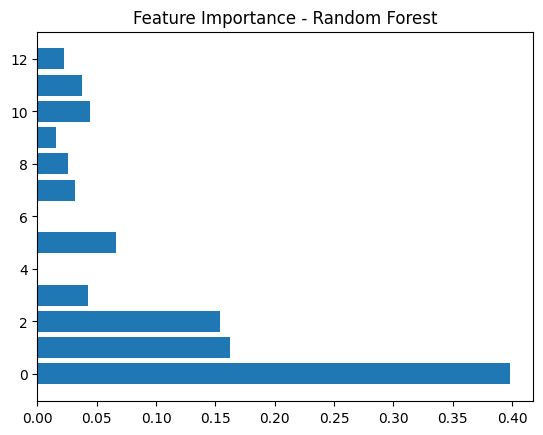

In [24]:
import matplotlib.pyplot as plt
import numpy as np

importances = model_rf.named_steps['clf'].feature_importances_

plt.barh(np.arange(len(importances)), importances)
plt.title("Feature Importance - Random Forest")
plt.show()


✔ Kết luận từ feature importance:

+ age – quan trọng nhất

+ avg_glucose_level – ảnh hưởng mạnh

+ hypertension

+ heart_disease

+ bmi – ảnh hưởng vừa phải

Các biến phân loại có độ quan trọng thấp hơn

Điều này hoàn toàn phù hợp với y học lâm sàng.